# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import (accuracy_score,
                             f1_score,
                             recall_score,
                             confusion_matrix,
                             classification_report,
                             precision_score)
print('Ecerything loaded Boss✅')

Ecerything loaded Boss✅


# **Data Exploration**

## *Load the Data*

In [2]:
file_path = input("Enter The File Path: ").replace('\\','\\')

df = pd.read_csv(file_path)

print("Data Loaded boss👍")

Data Loaded boss👍


## *Exploration*

In [3]:
print(f"The Dataset have {df.shape[0]} rows and {df.shape[1]} columns")

The Dataset have 633 rows and 8 columns


In [4]:
df.head()

,tenure_months,monthly_charges,num_services,support_calls,contract_type,avg_daily_usage_gb,payment_delays,churned
0,52.0,29.24,3.0,3.0,1.0,12.98,5.0,0
1,1.0,32.05,4.0,3.0,0.0,4.46,3.0,1
2,15.0,94.55,3.0,0.0,2.0,10.67,4.0,0
3,23.0,54.4,3.0,9.0,2.0,8.29,0.0,0
4,-5.0,78.79,6.0,1.0,0.0,12.71,1.0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 633 entries, 0 to 632
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tenure_months       633 non-null    float64
 1   monthly_charges     611 non-null    str    
 2   num_services        633 non-null    float64
 3   support_calls       612 non-null    float64
 4   contract_type       633 non-null    float64
 5   avg_daily_usage_gb  633 non-null    float64
 6   payment_delays      633 non-null    float64
 7   churned             633 non-null    int64  
dtypes: float64(6), int64(1), str(1)
memory usage: 42.8 KB


In [6]:
print(f"Dataset have {df.duplicated().sum()} duplicates")

Dataset have 13 duplicates


In [7]:
print('The dataset have NaN values in columns: ')
print(df.isna().sum())

The dataset have NaN values in columns: 
tenure_months          0
monthly_charges       22
num_services           0
support_calls         21
contract_type          0
avg_daily_usage_gb     0
payment_delays         0
churned                0
dtype: int64


# **Data Cleaning**

**Create Copy**

In [8]:
df_copy = df.copy()

**DataType**

In [9]:
df_copy['monthly_charges'] = df_copy['monthly_charges'].replace('_err','',regex=True).astype('float')

**Outliers**

In [10]:
columns = df_copy.select_dtypes(include='number').columns.tolist()
columns.remove('churned')

for col in columns:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_copy.loc[df_copy[col] < lower, col] = np.nan
    df_copy.loc[df_copy[col] > upper, col] = np.nan
    
print("Outliers Handled ✅")

Outliers Handled ✅


**Duplicates**

In [11]:
print(f"The dateset have {df_copy.duplicated().sum()} duplicates before dropping and after dropping the duplicates in the data is {df_copy.drop_duplicates(inplace=True)}")

The dateset have 13 duplicates before dropping and after dropping the duplicates in the data is None


**NaN Values**

In [12]:
columns = df_copy.select_dtypes(include='number').columns.tolist()
columns.remove('churned')

for col in columns:
    df_copy[col] = df_copy[col].fillna(round(df_copy[col].median(),2))
    
print("NaN values fill")

NaN values fill


# **Data preperation**

In [13]:
X = df_copy[['tenure_months',
             'monthly_charges',
             'num_services',
             'support_calls',
             'contract_type',
             'avg_daily_usage_gb',
             'payment_delays']]
y = df_copy['churned']

print(f"X shape: {X.shape}")
print(f'y Shape: {y.shape}')

X shape: (620, 7)
y Shape: (620,)


In [14]:
X_train,X_test,y_train,y_test = train_test_split(X,
                                                 y,
                                                 train_size=0.8,
                                                 random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f'y_train Shape: {y_train.shape}')
print(f'X_test Shape: {X_test.shape}')
print(f'y_test Shape: {y_test.shape}')

X_train shape: (496, 7)
y_train Shape: (496,)
X_test Shape: (124, 7)
y_test Shape: (124,)


# **Model**

## *Train*

In [15]:
model = DecisionTreeClassifier(max_depth=3,
                               min_samples_leaf=5,
                               min_samples_split=10,
                               random_state=42)

model.fit(X_train, y_train)
print("Model trained ✅")

Model trained ✅


## *Test*

In [16]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.65      0.68        63
           1       0.67      0.74      0.70        61

    accuracy                           0.69       124
   macro avg       0.70      0.69      0.69       124
weighted avg       0.70      0.69      0.69       124

[[41 22]
 [16 45]]


**Features Importance**

              Feature  Importance
0       tenure_months      0.3824
3       support_calls      0.2456
6      payment_delays      0.2238
2        num_services      0.1062
1     monthly_charges      0.0420
4       contract_type      0.0000
5  avg_daily_usage_gb      0.0000


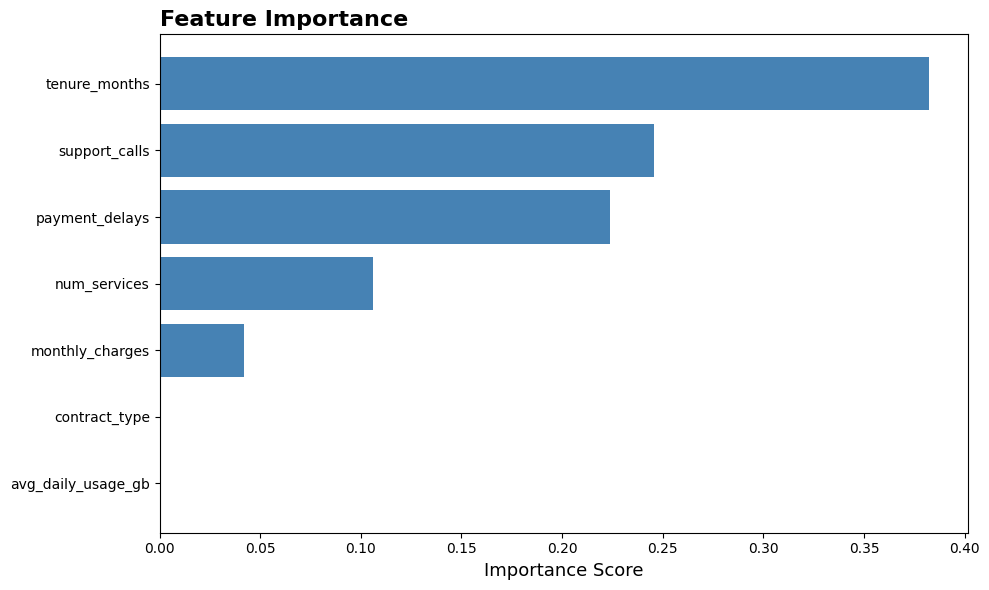

In [17]:
importance_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': model.feature_importances_.round(4)
}).sort_values('Importance', ascending=False)

print(importance_df)

# Plot it
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], 
         importance_df['Importance'], 
         color='steelblue')
plt.xlabel('Importance Score', fontsize=13)
plt.title('Feature Importance', fontsize=16, 
          fontweight='bold', loc='left')
ax = plt.gca()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Tree**

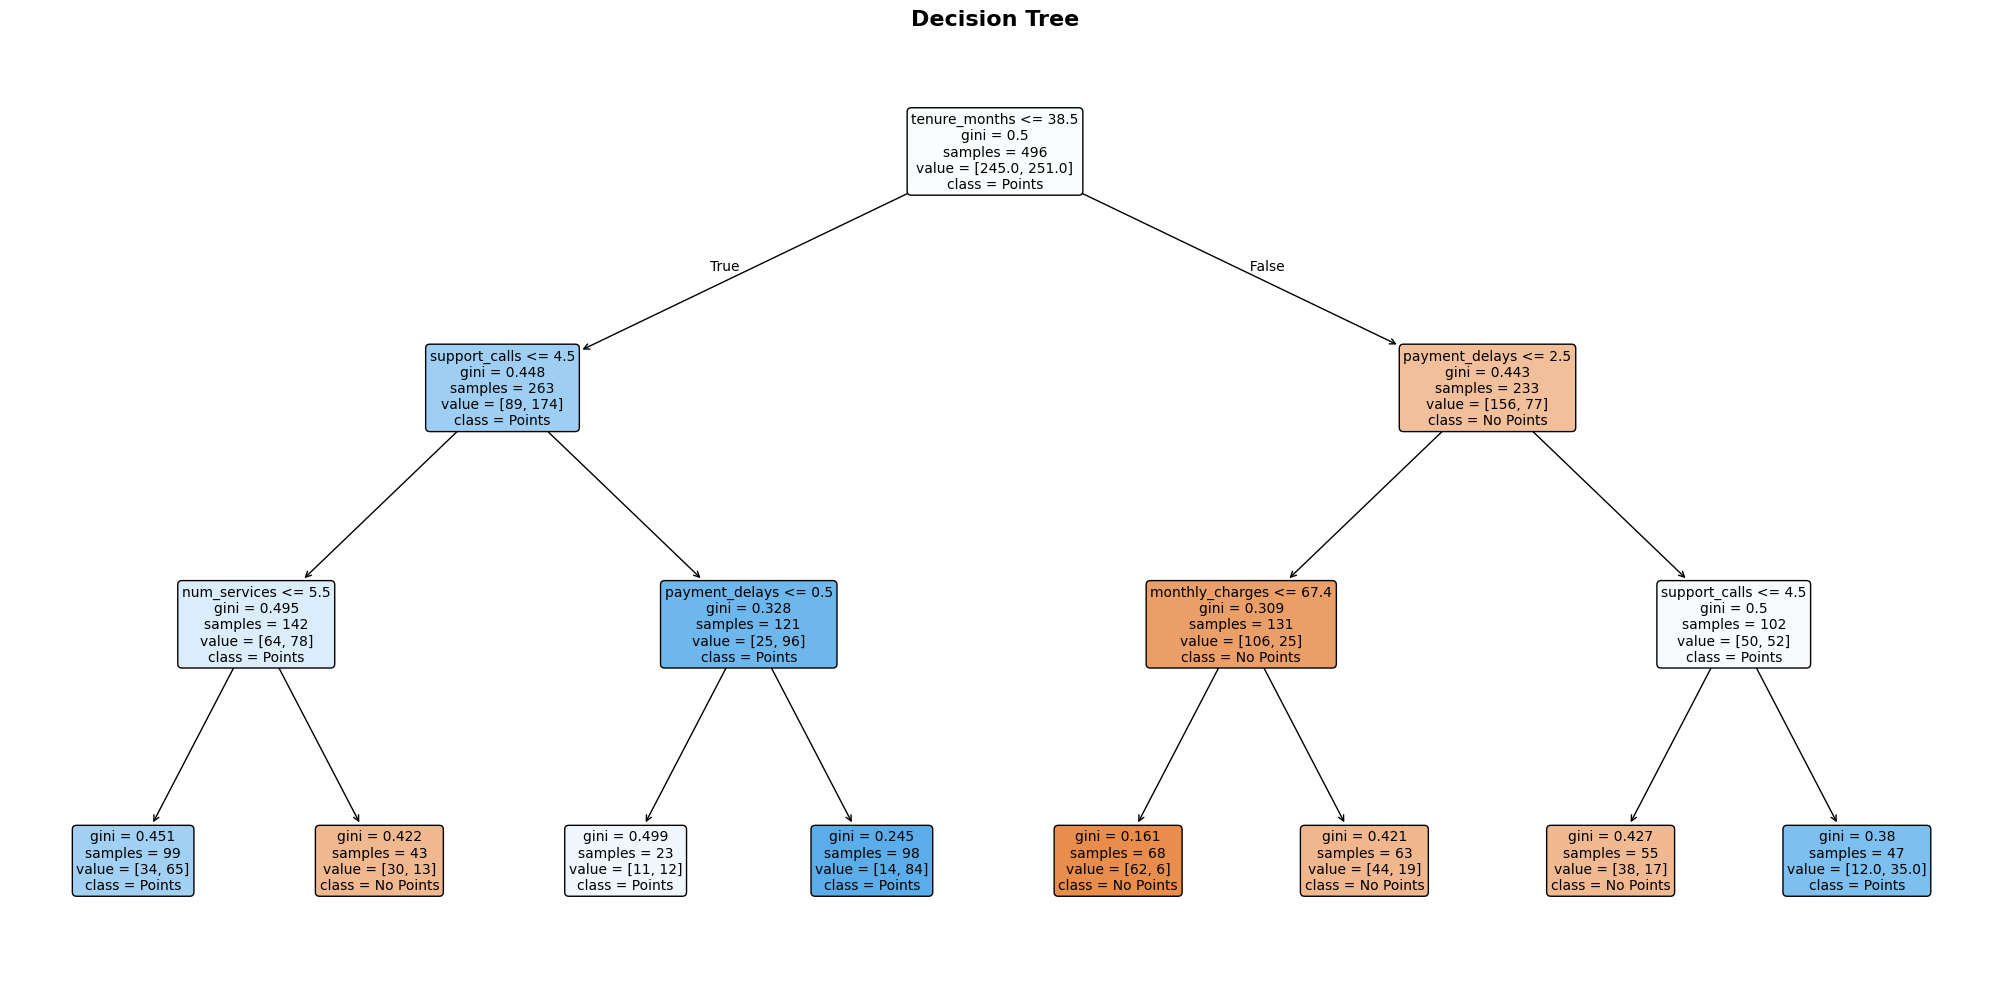

In [18]:
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns.tolist(),
    class_names=['No Points', 'Points'],
    filled=True,          # colour nodes by class
    rounded=True,         # rounded boxes
    fontsize=10
)

plt.title('Decision Tree', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Gap**

In [19]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc  = accuracy_score(y_test, test_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Gap:               {(train_acc - test_acc):.4f}")

Training Accuracy: 0.7460
Testing Accuracy:  0.6935
Gap:               0.0524


# **Chart**

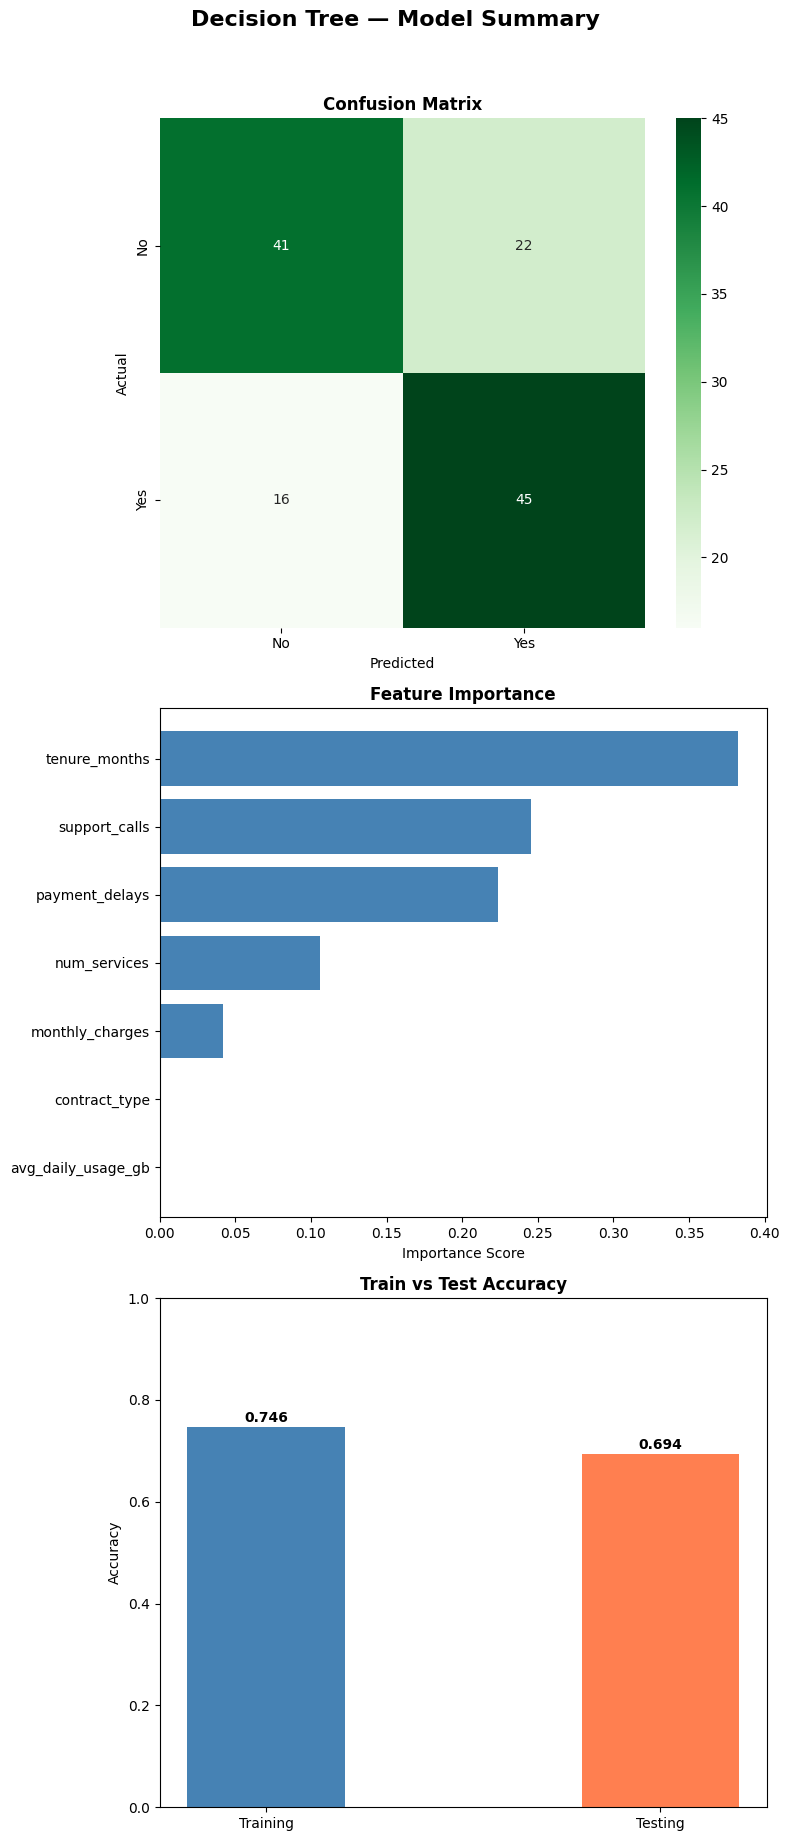

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(8, 18))

# --- Plot 1: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# --- Plot 2: Feature Importance ---
importance_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance')

axes[1].barh(importance_df['Feature'],
             importance_df['Importance'],
             color='steelblue')
axes[1].set_title('Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance Score')

# --- Plot 3: Train vs Test Accuracy ---
labels  = ['Training', 'Testing']
scores  = [train_acc, test_acc]
colors  = ['steelblue', 'coral']

axes[2].bar(labels, scores, color=colors, width=0.4)
axes[2].set_ylim(0, 1)
axes[2].set_title('Train vs Test Accuracy', fontweight='bold')
axes[2].set_ylabel('Accuracy')
for i, v in enumerate(scores):
    axes[2].text(i, v + 0.01, f'{v:.3f}', 
                 ha='center', fontweight='bold')

plt.suptitle('Decision Tree — Model Summary',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()